In [23]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

base_dir = Path.cwd().parent
img_path = base_dir/"data"/"cars"/"img01.jpg"
if not img_path.exists():
    raise FileNotFoundError("Khong tim thay file")
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("khong tim thay anh")
ret, thres_img = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
cv2.imshow("Simple threshold: ", thres_img)


In [24]:
thresh_mean = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
cv2.imshow("Adaptive threshold: ", thresh_mean)


In [25]:
ret,otsu_img = cv2.threshold(img,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2.imshow("Otsu threshold: ", otsu_img)


In [26]:
and_img = cv2.bitwise_and(img,img, mask = otsu_img)
cv2.imshow("And : ", and_img)


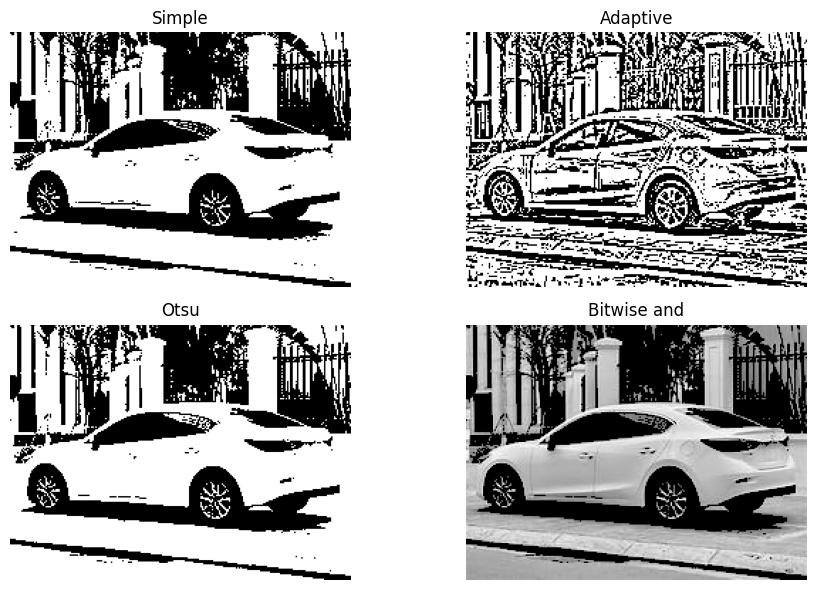

In [27]:
fig ,axes = plt.subplots(2,2,figsize = (10,6))
titles = ["Simple", "Adaptive", "Otsu", "Bitwise and"]
imgs = [thres_img,thresh_mean,otsu_img,and_img]
cmaps = ["gray","gray","gray","gray"]

for ax,title,im,cmap in zip(axes.flat,titles,imgs,cmaps):
    ax.imshow(im,cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()